<a href="https://colab.research.google.com/github/minhiungan2608/machine-failure-prediction-bert/blob/main/Last_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers datasets evaluate accelerate
!pip install seaborn matplotlib scikit-learn
!pip install kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00


In [ ]:
import os
os.environ["WANDB_PROJECT"] = "Machine_Failure_Prediction"
os.environ["WANDB_NAME"] = "BERT_Quantization_Run"
os.environ["WANDB_LOG_MODEL"] = "end"
os.environ["WANDB_WATCH"] = "false"

In [ ]:
!pip install --upgrade wandb
import os
import wandb

# No account or external logging is required for a default run.
os.environ.setdefault("WANDB_MODE", "disabled")
wandb.init(
    project="Machine_Failure_Prediction",
    name="BERT_Quantization_Run",
    reinit=False,
    settings=wandb.Settings(start_method="thread")
)


In [ ]:
from pathlib import Path

DATA_PATH = Path("machine_failure.csv")
if not DATA_PATH.is_file():
    try:
        from google.colab import files
        files.upload()
    except ImportError:
        pass
if not DATA_PATH.is_file():
    raise FileNotFoundError("Place machine_failure.csv in the notebook working directory.")


In [ ]:
import pandas as pd
# Use the included dataset from the notebook working directory.
df = pd.read_csv(DATA_PATH)
df.head()


In [ ]:
print("'Machine failure':")
print(df['Machine failure'].value_counts())

'Machine failure':
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [ ]:
import numpy as np
import random
import torch
import matplotlib.pyplot as plt
import seaborn as sns

RND = 42
np.random.seed(RND)
random.seed(RND)
torch.manual_seed(RND)

print("Torch device:", torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Torch device: False CPU


In [ ]:
# SIMPLE EDA
print("Columns:", df.columns.tolist()) #ls all columns in DataFrame
print("\nInfo:") #information
print(df.info())

print("\nDescribe:")
display(df.describe())

# If 'Machine failure' or 'machine_failure' in dataset, find the exact name:
possible_label_names = [c for c in df.columns if 'fail' in c.lower() or 'failure' in c.lower()]
print("\nDetected label-like columns:", possible_label_names)

Columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      1000

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000



Detected label-like columns: ['Machine failure']


In [ ]:
# NORMALIZE COLUMN NAMES AND IDENTIFY SENSOR + LABEL COLUMNS
# Check and map names:
expected_sensors = ['Air temperature [K]', 'Process temperature [K]',
                    'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]'] #ls expected sensors/ input features in the dataset

# ls all columns in df and print to check
cols = df.columns.tolist()
print("All columns:", cols)

COLUMN_MAPPING = {} # empty DICT to map old col --> new col

# Apply mapping if provided
if COLUMN_MAPPING:
    df = df.rename(columns=COLUMN_MAPPING)

# Find sensor columns that exist
sensor_cols = [c for c in expected_sensors if c in df.columns]
if len(sensor_cols) < len(expected_sensors):
    print("Not all default sensor columns found.")
    print("Detected sensors:", sensor_cols)
else:
    print("Detected sensor columns:", sensor_cols)

# Detect label column automatically:
label_col = None
for c in df.columns:
    if c.lower() in ['machine failure', 'machine_failure', 'machinefailure', 'failure', 'machine failure (1=fail)']:
        label_col = c
        break

# If not available, try to find any column with 0/1
if label_col is None:
    for c in df.columns:
        if set(df[c].dropna().unique()).issubset({0,1}):
            label_col = c
            break

print("Using label column:", label_col)

All columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
Detected sensor columns: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
Using label column: Machine failure


In [ ]:
from sklearn.preprocessing import StandardScaler

# Check missing values
print("Missing per column:\n", df.isna().sum()) # No missing values, but keep for reusability

# Handle missing values
if df.isna().sum().sum() > 0:
    df = df.ffill().bfill()
    print("Missing values filled")
else:
    print("No missing values detected")

# Scale sensors
scaler = StandardScaler() # z = (x - mean) / std
df[sensor_cols] = scaler.fit_transform(df[sensor_cols]) # mean = 0; std= 1

print("After scaling (head):")
display(df[sensor_cols].head()) # print scaled result

Missing per column:
 UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64
No missing values detected
After scaling (head):


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,-0.952389,-0.947360,0.068185,0.282200,-1.695984
1,-0.902393,-0.879959,-0.729472,0.633308,-1.648852
2,-0.952389,-1.014761,-0.227450,0.944290,-1.617430
3,-0.902393,-0.947360,-0.590021,-0.048845,-1.586009
4,-0.902393,-0.879959,-0.729472,0.001313,-1.554588


* Missing values: 0
* Sensor columns: Already normalized (mean=0, std=1)
* Data is ready for BERT

In [ ]:
# SLIDING WINDOW → create sequences (X) and labels (y)
import numpy as np

WINDOW_SIZE = 20   # Number of timesteps per window
STRIDE = 1
# --> STRIDE = 1:
# Window 1: rows [0-19]
# Window 2: rows [1-20]
# Window 3: rows [2-21]
values = df[sensor_cols].values # values: Numpy array containing sensor columns (already scaled)
labels = df[label_col].astype(int).values # labels: Numpy array containing labels (Machine failure)

def create_windows(values, labels, window_size=WINDOW_SIZE, stride=STRIDE):
    Xw, yw = [], []
    # Xw: List with windows (features)
    # yw: List with lables
    L = len(values) # L = all rows in dataset
    for i in range(0, L - window_size + 1, stride):
        w = values[i:i+window_size]            # shape (window_size, n_sensors)
        lab = int(labels[i:i+window_size].max())  # if any failure in window -> label=1
      # Add into lists
        Xw.append(w)
        yw.append(lab)
    return np.array(Xw), np.array(yw) # convert ls into numpy arrays

X_w, y_w = create_windows(values, labels)
print("Created windows:", X_w.shape, y_w.shape)
print("Label distribution in windows:", np.bincount(y_w))

Created windows: (9981, 20, 5) (9981,)
Label distribution in windows: [5974 4007]


In [ ]:
# K-MEANS QUANTIZATION
from sklearn.cluster import KMeans

NUM_TOKENS = 64   # Vocab size (optimal: 32-256)
n_sensors = X_w.shape[-1]
print("n_sensors:", n_sensors)

# Fit k-means on all timestep vectors
all_vectors = X_w.reshape(-1, n_sensors)   # shape (n_windows * window_size, n_sensors)
print("Fitting KMeans on", all_vectors.shape, "vectors ...")
kmeans = KMeans(n_clusters=NUM_TOKENS, random_state=RND, n_init=10).fit(all_vectors)

# Convert each timestep vector to a token id
def window_to_tokens(window):
    # window shape: (window_size, n_sensors)
    return [int(lbl) for lbl in kmeans.predict(window)]

tokenized = [window_to_tokens(w) for w in X_w]
print("Example token sequence (1 window):", tokenized[0][:20], "... length:", len(tokenized[0]))

n_sensors: 5
Fitting KMeans on (199620, 5) vectors ...
Example token sequence (1 window): [9, 59, 59, 9, 59, 59, 9, 9, 50, 24, 24, 11, 20, 24, 7, 29, 11, 11, 20, 38] ... length: 20


In [ ]:
# Prepare input_ids (padded) and attention_mask
import torch
from datasets import Dataset, DatasetDict

MAX_LEN = WINDOW_SIZE

input_ids = [seq[:MAX_LEN] + [NUM_TOKENS]*max(0, MAX_LEN - len(seq)) for seq in tokenized]  # Pad with NUM_TOKENS
attention_mask = [[1]*min(len(seq), MAX_LEN) + [0]*max(0, MAX_LEN - len(seq)) for seq in tokenized] # attention mask purpose: let BERT separate real token and padding token

# Confirm pad id (NUM_TOKENS) is currently the pad token
pad_token_id = NUM_TOKENS # let BERT know padding when train

# Create HuggingFace dataset from dictionary
ds = Dataset.from_dict({
    "input_ids": input_ids,
    "attention_mask": attention_mask,
    "labels": y_w.tolist()
})

# Split train/test (random seed for reproducibility)
ds = ds.train_test_split(test_size=0.2, seed=RND) # 20% test/ 80% train
print(ds)

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 7984
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 1997
    })
})


In [ ]:
# Dictionary Structure
# 3 components:
# input_ids: Tokenized sequences (padded)
# attention_mask: Which tokens to attend
# labels: Target values (failure or not)
{
    "input_ids": [
        [9, 59, 59, ..., 20],      # Sequence 0
        [19, 59, 59, ..., 38],     # Sequence 1
        ...
    ],
    "attention_mask": [
        [1, 1, 1, ..., 1],         # Mask for sequence 0
        [1, 1, 1, ..., 1],         # Mask for sequence 1
        ...
    ],
    "labels": [0, 0, 1, 0, ...]    # Labels (0 or 1)
}

{'input_ids': [[9, 59, 59, Ellipsis, 20],
  [19, 59, 59, Ellipsis, 38],
  Ellipsis],
 'attention_mask': [[1, 1, 1, Ellipsis, 1], [1, 1, 1, Ellipsis, 1], Ellipsis],
 'labels': [0, 0, 1, 0, Ellipsis]}

In [ ]:
# CALCULATE CLASS WEIGHTS
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

# Get labels from the training set
train_labels = ds["train"]["labels"]

# Calculate class weights
# 'balanced' automatically calculates weights inversely proportional to class frequencies
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Convert weights to PyTorch tensor
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
print("Class weights:", class_weights_tensor)

Class weights: tensor([0.8308, 1.2557])


In [ ]:
# BUILD BERT CONFIG & MODEL
from transformers import BertConfig, BertForSequenceClassification

vocab_size = NUM_TOKENS + 1  # +1 for PAD token id
config = BertConfig(
    vocab_size=vocab_size,
    hidden_size=128,
    num_hidden_layers=4,
    num_attention_heads=4,
    intermediate_size=512,
    max_position_embeddings=512,
    pad_token_id=pad_token_id,
    num_labels=2
)

model = BertForSequenceClassification(config)
print(model.config)

BertConfig {
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 128,
  "initializer_range": 0.02,
  "intermediate_size": 512,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 4,
  "num_hidden_layers": 4,
  "pad_token_id": 64,
  "position_embedding_type": "absolute",
  "transformers_version": "4.57.2",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 65
}



In [ ]:
import torch
from transformers import TrainingArguments, Trainer
import evaluate
import numpy as np
from torch import nn

# Metrics
acc_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": acc_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1": f1_metric.compute(predictions=preds, references=labels)["f1"]
    }

# Define a custom Trainer subclass to override the compute_loss method
class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        # Use class_weights_tensor in CrossEntropyLoss
        loss_fct = nn.CrossEntropyLoss(weight=class_weights_tensor.to(logits.device))
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir="bert_failure_out",
    learning_rate=3e-4,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=128,
    num_train_epochs=8,
    weight_decay=0.01,

    # REMOVE problematic arguments
    logging_steps=50,
    save_steps=500,
    # no eval strategy → no load_best_model_at_end
    load_best_model_at_end=False
)

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=ds["train"],
    eval_dataset=ds["test"],
    tokenizer=None,
    compute_metrics=compute_metrics
)

print("Trainer is ready.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


/tmp/ipython-input-706461378.py:45: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `CustomTrainer.__init__`. Use `processing_class` instead.
  trainer = CustomTrainer(


Trainer is ready.


In [ ]:
# TRAIN
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss
50,0.632800
100,0.597400
150,0.579600
200,0.568700
250,0.544500
300,0.527500
350,0.509300
400,0.519800
450,0.487400
500,0.494300


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=1000, training_loss=0.5056363277435303, metrics={'train_runtime': 310.8669, 'train_samples_per_second': 205.464, 'train_steps_per_second': 3.217, 'total_flos': 6209232168960.0, 'train_loss': 0.5056363277435303, 'epoch': 8.0})

In [ ]:
# EVALUATE
eval_res = trainer.evaluate()
print("Eval results:", eval_res)

# Predict on test to get confusion matrix, probs
pred_out = trainer.predict(ds["test"])
logits = pred_out.predictions
probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:,1]
preds = np.argmax(logits, axis=-1)
labels = pred_out.label_ids

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Eval results: {'eval_loss': 0.4676198959350586, 'eval_accuracy': 0.771657486229344, 'eval_f1': 0.7379310344827587, 'eval_runtime': 2.68, 'eval_samples_per_second': 745.144, 'eval_steps_per_second': 5.97, 'epoch': 8.0}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Confusion Matrix:
 [[899 270]
 [186 642]]


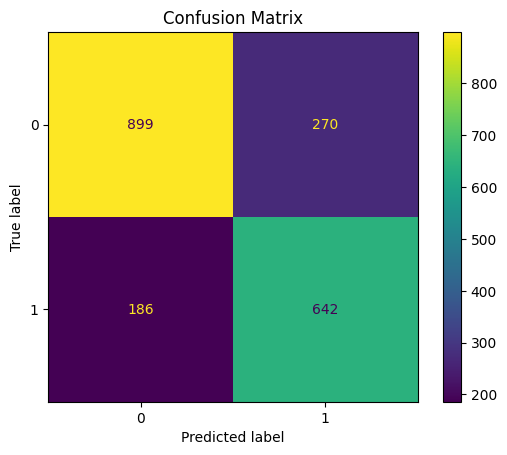


Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.77      0.80      1169
           1       0.70      0.78      0.74       828

    accuracy                           0.77      1997
   macro avg       0.77      0.77      0.77      1997
weighted avg       0.78      0.77      0.77      1997



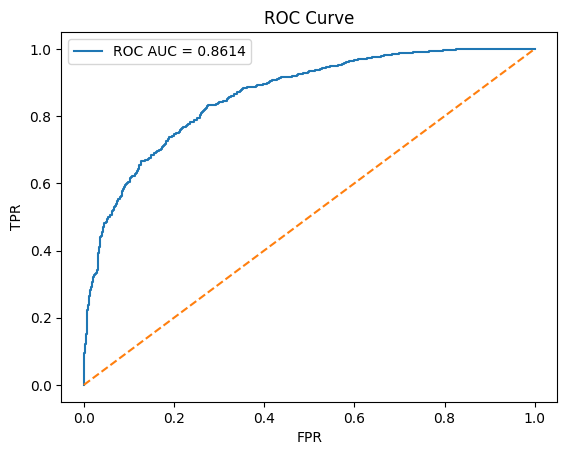

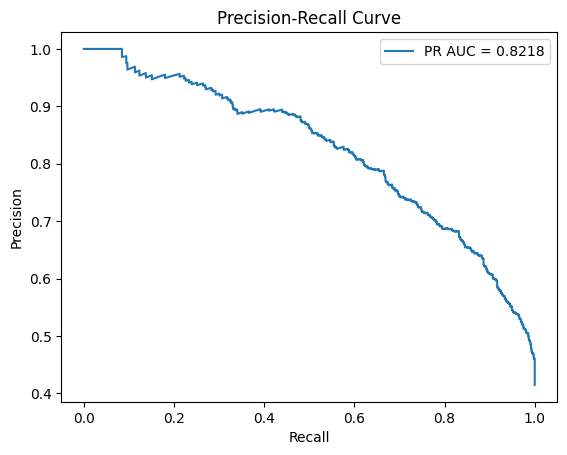

In [ ]:
# VISUALIZATION: Confusion Matrix + ROC + PR Curves
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, precision_recall_curve, auc, classification_report

# Confusion matrix
cm = confusion_matrix(labels, preds)
print("Confusion Matrix:\n", cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# Classification report
print("\nClassification Report:\n", classification_report(labels, preds))

# ROC AUC
roc_auc = roc_auc_score(labels, probs)
fpr, tpr, _ = roc_curve(labels, probs)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC Curve"); plt.legend()
plt.show()

# PR curve
precision, recall, _ = precision_recall_curve(labels, probs)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.4f}")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall Curve"); plt.legend()
plt.show()

In [ ]:
# SAVE MODEL & ARTIFACTS
import os
out_dir = "exported_model"
os.makedirs(out_dir, exist_ok=True)

# Save model weights + config
model.save_pretrained(out_dir)

# Save KMeans centroids (codebook) for inference later
import joblib
joblib.dump(kmeans, os.path.join(out_dir, "kmeans_codebook.joblib"))

# Save sensor scaler so that inference can apply same scaling
joblib.dump(scaler, os.path.join(out_dir, "sensor_scaler.joblib"))

# Zip everything
!zip -r exported_model.zip {out_dir}
print("Saved model and artifacts to", out_dir, "and zipped.")

  adding: exported_model/ (stored 0%)
  adding: exported_model/model.safetensors (deflated 7%)
  adding: exported_model/kmeans_codebook.joblib (deflated 97%)
  adding: exported_model/config.json (deflated 48%)
  adding: exported_model/sensor_scaler.joblib (deflated 35%)
Saved model and artifacts to exported_model and zipped.


In [ ]:
# INFERENCE FUNCTION FOR A NEW SENSOR SEQUENCE
import numpy as np
import joblib
from transformers import BertForSequenceClassification

# Load artifacts
kmeans = joblib.load("exported_model/kmeans_codebook.joblib")
scaler = joblib.load("exported_model/sensor_scaler.joblib")
model = BertForSequenceClassification.from_pretrained("exported_model")
model.eval()
if torch.cuda.is_available():
    model.to("cuda")

def predict_window(sensor_window):
    """
    sensor_window: numpy array shape (window_size, n_sensors)
    returns: probability of failure in that window
    """
    # Scale input
    sensor_window = scaler.transform(sensor_window)
    # Quantize to tokens
    tokens = [int(t) for t in kmeans.predict(sensor_window)]
    # Pad if needed
    if len(tokens) < MAX_LEN:
        tokens = tokens + [pad_token_id] * (MAX_LEN - len(tokens))
    input_ids = torch.tensor([tokens], dtype=torch.long)
    attention_mask = torch.tensor([[1]*len(tokens)], dtype=torch.long)
    if torch.cuda.is_available():
        input_ids = input_ids.to("cuda"); attention_mask = attention_mask.to("cuda")
    with torch.no_grad():
        out = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = out.logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0,1]
    return float(probs)

# Example: take the first window
example_window = X_w[0]
print("Example window failure prob:", predict_window(example_window))

Example window failure prob: 0.9154743552207947


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
